In [1]:
import os
os.chdir('/workspaces/korea-real-estate-population-movement')

from src.config import DB_URL
import pandas as pd
from sqlalchemy import create_engine, inspect
import matplotlib.pyplot as plt

In [2]:
# Add Korean font
import matplotlib.font_manager as fm
fm.fontManager.addfont(
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
)
[f.name for f in fm.fontManager.ttflist if "Nanum" in f.name]
plt.rcParams["font.family"] = "NanumGothic"

In [3]:
engine = create_engine(DB_URL)

# Helper function to read sql file
def read_sql_file(path):
    with open(path,"r") as f:
        return f.read()


In [4]:
# Inspect tables before calling data

inspector = inspect(engine)

for table in inspector.get_table_names():
    print(f"\n--- {table} ---")
    
    for column in inspector.get_columns(table):
        print(column["name"], column["type"])


--- seoul_population_flow ---
date INTEGER
from_province VARCHAR(50)
to_province VARCHAR(50)
from_district VARCHAR(50)
to_district VARCHAR(50)
total_people INTEGER
male INTEGER
female INTEGER

--- seoul_apartment_sales ---
month INTEGER
district VARCHAR(50)
units_sold INTEGER

--- district_code_dim ---
code VARCHAR(10)
district VARCHAR(50)

--- individual_apt_sales ---
id INTEGER
apt_name VARCHAR(50)
build_year INTEGER
deal_date INTEGER
floor INTEGER
district_code VARCHAR(5)
price_manwon INTEGER
size_m2 NUMERIC
unit VARCHAR(20)
dong VARCHAR(10)


In [ ]:
df = pd.read_sql(
    f"SELECT * FROM seoul_population_flow LIMIT 5",
    engine
)

display(df)


# Districts with the highest number of inflow and outflow

In [5]:
cumulative_outflow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/top_five_cumulative_outflow.sql')
yearly_top_outflow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/yearly_top_outflow.sql')

top_outflow_districts = pd.read_sql_query(cumulative_outflow_query,engine)
yearly_outflow = pd.read_sql_query(yearly_top_outflow_query,engine)

display(top_outflow_districts)
display(yearly_outflow)

,from_district,total_outflow
0,강남구,111479
1,송파구,91461
2,강동구,87685
3,서초구,81438
4,관악구,74563


,from_district,year,total_outflow
0,강남구,2023,40941
1,송파구,2023,29824
2,서초구,2023,27351
3,관악구,2023,23259
4,강동구,2023,18988
5,강남구,2024,38734
6,강동구,2024,32250
7,송파구,2024,31433
8,서초구,2024,25268
9,관악구,2024,24842


In [6]:
cumulative_inflow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/top_five_cumulative_inflow.sql')
yearly_top_inflow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/yearly_top_inflow.sql')

top_inflow_districts = pd.read_sql_query(cumulative_inflow_query,engine)
yearly_inflow = pd.read_sql_query(yearly_top_inflow_query,engine)

display(top_inflow_districts)
display(yearly_inflow)

,to_district,total_inflow
0,송파구,97488
1,강남구,95996
2,관악구,90329
3,동작구,76480
4,영등포구,75434


,to_district,year,total_inflow
0,강남구,2023,30791
1,관악구,2023,30381
2,송파구,2023,30054
3,동작구,2023,25378
4,영등포구,2023,24706
5,송파구,2024,32235
6,강남구,2024,31058
7,관악구,2024,30442
8,동작구,2024,25229
9,영등포구,2024,24932


## Observation

- After identifying districts with high inflow and outflow, we have decided to focus on the 7 districts that fall in that category: Gangnam, Songpa, Gangdong, Seocho, Gwanak, Dongjak, Yeongdeungpo. 

- Next, we are going to query the turnover rate of each of these districts over the last three years. 
    - Turnover = Inflow + Outflow

In [7]:
yearly_turnover_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/yearly_turnover.sql')
yearly_turnover = pd.read_sql_query(yearly_turnover_query,engine)

display(yearly_turnover)

,district,year,total_outflow,total_inflow,turnover
0,강남구,2023,40941,30791,71732
1,송파구,2023,29824,30054,59878
2,관악구,2023,23259,30381,53640
3,서초구,2023,27351,25056,52407
4,동작구,2023,22961,25378,48339
5,영등포구,2023,23314,24706,48020
6,강동구,2023,18988,16513,35501
7,강남구,2024,38734,31058,69792
8,송파구,2024,31433,32235,63668
9,관악구,2024,24842,30442,55284


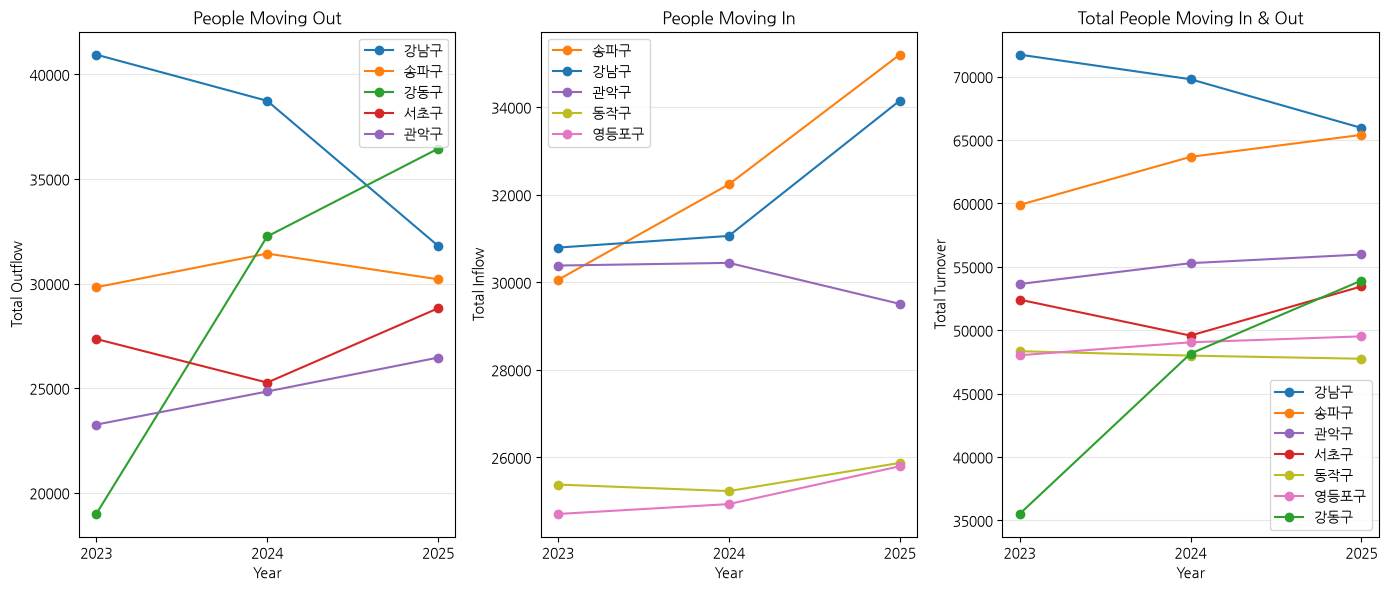

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(14,6))

district_colors = {
    "강남구": "tab:blue",
    "송파구": "tab:orange",
    "강동구": "tab:green",
    "서초구": "tab:red",
    "관악구": "tab:purple",
    "동작구": "tab:olive",
    "영등포구": "tab:pink"
}

for district in top_outflow_districts['from_district']:
    district_df = yearly_outflow[yearly_outflow['from_district'] == district]
    ax1.plot(
        district_df['year'],
        district_df['total_outflow'],
        marker="o",
        label=district,
        color=district_colors[district]
    )

ax1.set_xticks([2023, 2024, 2025])
ax1.set_xlabel("Year")
ax1.set_ylabel("Total Outflow")
ax1.set_title("People Moving Out")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

for district in top_inflow_districts['to_district']:
    district_df = yearly_inflow[yearly_inflow['to_district'] == district]

    ax2.plot(
        district_df['year'],
        district_df['total_inflow'],
        marker='o',
        label=district,
        color=district_colors[district]
    )

ax2.set_xticks([2023, 2024, 2025])
ax2.set_xlabel("Year")
ax2.set_ylabel("Total Inflow")
ax2.set_title("People Moving In")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

for district in yearly_turnover['district'].unique():
    district_df = yearly_turnover[yearly_turnover['district'] == district]

    ax3.plot(
        district_df['year'],
        district_df['turnover'],
        marker='o',
        label=district,
        color=district_colors[district]
    )

ax3.set_xticks([2023, 2024, 2025])
ax3.set_xlabel('Year')
ax3.set_ylabel('Total Turnover')
ax3.set_title('Total People Moving In & Out')
ax3.legend()
ax3.grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.show()

Outflow & Inflow Observations:

- Gangnam's net population movement has shifted from negative to positive.
    - Outflow: ~41K -> ~39K -> ~32K
    - Inflow: ~31K -> ~32K -> ~34K
- Gangdong has a huge increase in outflow over the three years
    - ~19K -> ~32K -> ~36K
    - Why did Gangdong record such large increases in resident outflow?
- Songpa is gaining population
    - While outflow stayed relatively steady, inflow is showing a increasing trend
        - Inflow: ~30K -> ~33K -> ~35K
- Gwanak's net population movement is becoming increasingly negative
    - Pairing a slow steady increase in outflow and decrease in inflow, Gwanak is slowly decreasing its overall net movement

Turnover Observations:
- Gangnam has the highest turnover with recently also recording a net positive population movement.
    - It has the highest amount of activity amongst the 7 districts.
- Songpa displays an increasing turnover trend over the last three years.
    - Songpa records the highest number of residents moving in while almost closing the gap with Gangnam for the highest turnover.
    - Songpa's population is growing in a city, creating a growing net positive population movement
- Gangdong, however, is the opposite. Although it has a increasing turnover trend in the observation period, Gangdong surpassed as the number 1 spot for highest residents moving out in 2025. 

 

# Individual Apartment Sales Data in Seoul

Individual Apartment Sales data holds every transaction of an apartment sale in Seoul. 

In [9]:
inspector = inspect(engine)

for column in inspector.get_columns('individual_apt_sales'):
    print(column["name"], column["type"])

id INTEGER
apt_name VARCHAR(50)
build_year INTEGER
deal_date INTEGER
floor INTEGER
district_code VARCHAR(5)
price_manwon INTEGER
size_m2 NUMERIC
unit VARCHAR(20)
dong VARCHAR(10)


In [10]:
top_transaction_districts_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/top_five_transactions.sql')

top_transaction_districts = pd.read_sql(top_transaction_districts_query,engine)

display(top_transaction_districts)

,district,transaction_count
0,송파구,11905
1,노원구,11725
2,강동구,10003
3,강남구,9491
4,성북구,8728


## Observation on cumulative transaction count from 2023 - 2025

Observation:
- Songpa's interesting relationship
    - Highest apartment transaction volume
    - High Inflow
    - Stable Outflow
    - Increasing Turnover
- Nowon and Sungbook did not appear in our earlier observations. This may be a indication high apartment transaction activity doesn't necessarily correlate to a high population flow pattern.
- Gangdong
    - 3rd largest transaction volume
    - Sharp increase in outflow and turnover
    - Could Gangdong's high population movement be associated with its high housing transaction activity?
- Gangnam
    - Highest turnover amongst our 7 districts
    - Declining outflow
    - Increasing inflow
    - 4th highest transaction volume


In [16]:
# Transaction for the 5 district for each year

yearly_top_transactions_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/yearly_top_transaction.sql')
yearly_top_transactions = pd.read_sql(yearly_top_transactions_query,engine)

display(yearly_top_transactions)

,district,deal_year,transaction_count
0,송파구,2023,2292
1,노원구,2023,2264
2,강남구,2023,1955
3,강동구,2023,1782
4,성북구,2023,1634
5,송파구,2024,4269
6,노원구,2024,3998
7,강남구,2024,3599
8,강동구,2024,3180
9,성북구,2024,2901


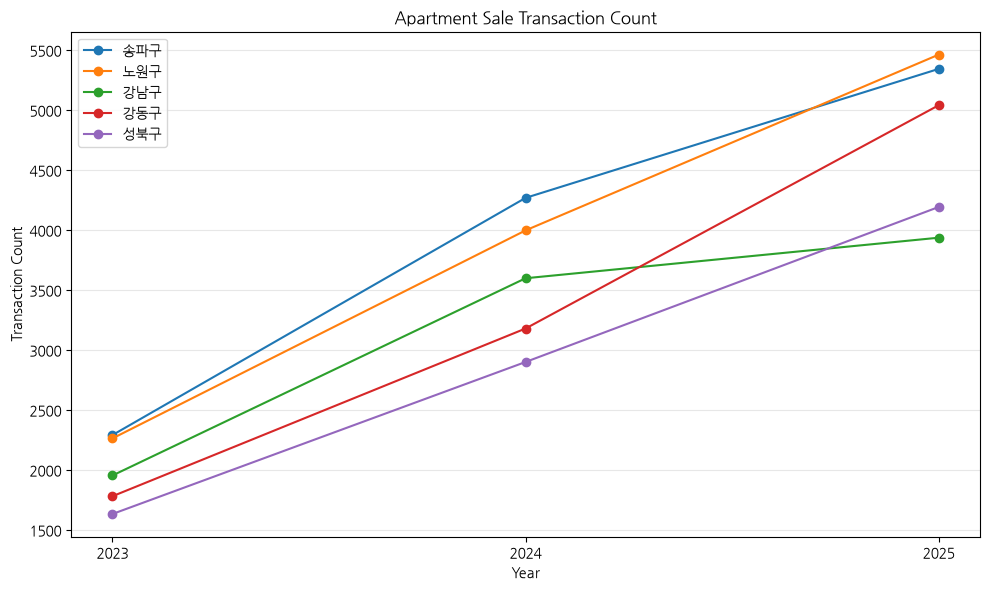

In [17]:
district_colors = {
    "강남구": "tab:blue",
    "송파구": "tab:orange",
    "강동구": "tab:green",
    "서초구": "tab:red",
    "관악구": "tab:purple",
    "동작구": "tab:olive",
    "영등포구": "tab:pink",
    "성북구": "tab:brown",
    "노원구": "tab:gray"
}

fig, ax = plt.subplots(figsize=(10,6))

for district in yearly_top_transactions['district'].unique():
    district_df = yearly_top_transactions[yearly_top_transactions['district'] == district]

    ax.plot(
        district_df['deal_year'],
        district_df['transaction_count'],
        marker='o',
        label=district
    )

ax.set_xticks([2023, 2024, 2025])
ax.set_xlabel('Year')
ax.set_ylabel('Transaction Count')
ax.set_title('Apartment Sale Transaction Count')
ax.legend()
ax.grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.show()

## Apartment Sale Transaction Observation

- Every district increased substantially over the 3 years
- Songpa and Nowon had the highest transaction activity with Nowon surpassing Songpa for the top spot.
- Gangdong had the sharpest increase in transaction count
    - Sharp increase in both Population Outflow and Apartment Transactions
- Gangnam by year 2025 had the lowest transaction count out of the 5 districts. 
    - Note: Gangnam had the highest population turnover 

In [ ]:
# Combine population flow and sale transaction df

yearly_top_transactions = yearly_top_transactions.rename(columns={"deal_year":"year"})

combined_df = yearly_top_transactions.merge(
    yearly_turnover,
    on=['district','year'],
    how='inner'
    )

for district in combined_df['district'].unique():
    display(combined_df[combined_df['district'] == district])



,district,year,transaction_count,total_outflow,total_inflow,turnover
0,송파구,2023,2292,29824,30054,59878
3,송파구,2024,4269,31433,32235,63668
6,송파구,2025,5344,30204,35199,65403


,district,year,transaction_count,total_outflow,total_inflow,turnover
1,강남구,2023,1955,40941,30791,71732
4,강남구,2024,3599,38734,31058,69792
8,강남구,2025,3937,31804,34147,65951


,district,year,transaction_count,total_outflow,total_inflow,turnover
2,강동구,2023,1782,18988,16513,35501
5,강동구,2024,3180,32250,15898,48148
7,강동구,2025,5041,36447,17466,53913


## Observations

- Songpa experienced increasing apartment transaction activity alongside increasing population inflow and turnover.
- Gangnam, on the other hand, recorded an increasing apartment transaction activity despite decreasing turnover. 
    - This suggest higher transaction activity did not correspond with increased population movement during the observation period.
- Gangdong experienced increasing apartment transaction activity alongside population outflow, and turnover. Because Gangdong's population inflow remained relatively steady, Gangdong's increased turnover is primarily driven by outflow. 
    - This raises the question, what could explain why Gangdong between 2023 and 2025 experienced simultaneous increase in apartment transactions and resident outflow?

# Hypothesis Testing

Does apartment transaction activity correlate with population movement
    - Transaction <-> Outflow
    - Transaction <-> Inflow
    - Transaction <-> Turnover

For this testing we will data monthly data from 2023 - 2025. 


## Transaction vs Outflow

H₀: There is no statistically significant relationship between monthly apartment transaction activity and monthly population outflow.

H₁: There is a statistically significant relationship between monthly apartment transaction activity and monthly population outflow.

In [24]:
monthly_transaction_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/monthly_transactions.sql')
monthly_population_flow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/monthly_population_flow.sql')

monthly_transaction = pd.read_sql(monthly_transaction_query,engine)
monthly_population_flow = pd.read_sql(monthly_population_flow_query,engine)

display(monthly_transaction)
display(monthly_population_flow)


,district,date,avg_price_m2,avg_build_age,avg_floor,transactions
0,송파구,202303,1934.67,21.69,12.94,232
1,강남구,202303,2412.72,27.42,8.70,183
2,강동구,202303,1316.86,16.84,9.96,178
3,송파구,202304,1848.28,22.77,11.68,281
4,강동구,202304,1314.55,18.19,11.47,226
...,...,...,...,...,...,...
97,강남구,202511,3127.48,23.33,9.29,266
98,강동구,202511,1544.93,21.25,9.95,110
99,송파구,202512,2316.73,26.62,9.40,311
100,강동구,202512,1541.59,21.60,9.82,213


,district,date,inflow,outflow,turnover
0,강남구,202301,2420,2306,4726
1,강동구,202301,1091,1337,2428
2,송파구,202301,2020,2340,4360
3,송파구,202302,2969,3455,6424
4,강남구,202302,3272,3849,7121
...,...,...,...,...,...
103,강남구,202511,2331,2287,4618
104,송파구,202511,2180,1790,3970
105,강남구,202512,2944,2992,5936
106,송파구,202512,2837,2535,5372


In [25]:
combined_df = monthly_transaction.merge(
    monthly_population_flow,
    on=['district','date'],
    how='inner'
)

display(combined_df)

,district,date,avg_price_m2,avg_build_age,avg_floor,transactions,inflow,outflow,turnover
0,송파구,202303,1934.67,21.69,12.94,232,3170,2804,5974
1,강남구,202303,2412.72,27.42,8.70,183,2722,4504,7226
2,강동구,202303,1316.86,16.84,9.96,178,1508,1605,3113
3,송파구,202304,1848.28,22.77,11.68,281,2380,2406,4786
4,강동구,202304,1314.55,18.19,11.47,226,1276,1280,2556
...,...,...,...,...,...,...,...,...,...
97,강남구,202511,3127.48,23.33,9.29,266,2331,2287,4618
98,강동구,202511,1544.93,21.25,9.95,110,1293,1526,2819
99,송파구,202512,2316.73,26.62,9.40,311,2837,2535,5372
100,강동구,202512,1541.59,21.60,9.82,213,1693,1935,3628


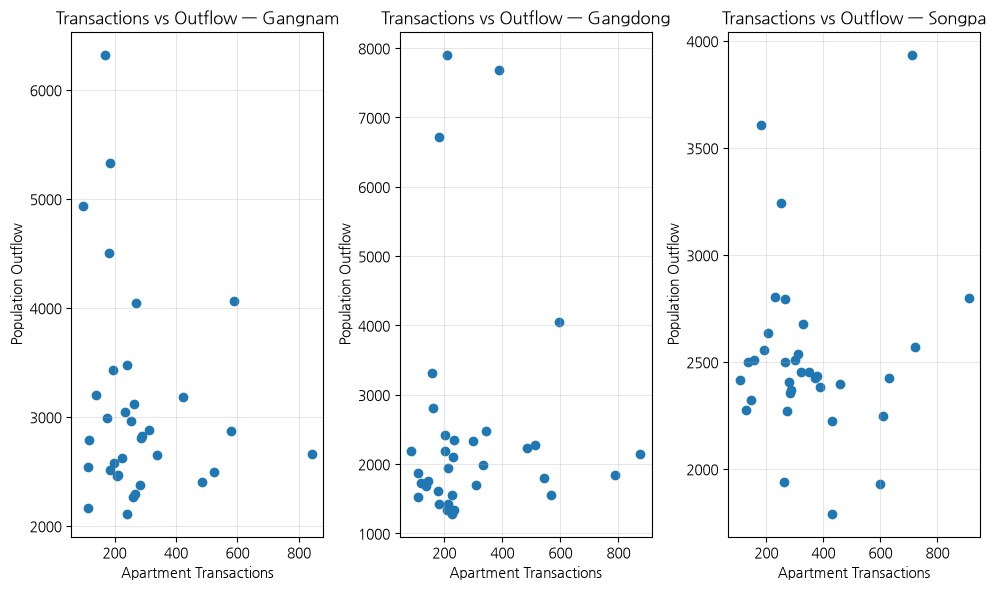

In [29]:
# Scatter plot of transactions vs Inflow, Outflow, and Turnover

fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(10,6))

gangnam = combined_df[combined_df['district'] == '강남구']
gangdong = combined_df[combined_df['district'] == '강동구']
songpa = combined_df[combined_df['district'] == '송파구']

ax1.scatter(
    gangnam['transactions'],
    gangnam['outflow']
)

ax1.set_xlabel('Apartment Transactions')
ax1.set_ylabel('Population Outflow')
ax1.set_title("Transactions vs Outflow — Gangnam")
ax1.grid(alpha=0.3)

ax2.scatter(
    gangdong['transactions'],
    gangdong['outflow']
)

ax2.set_xlabel('Apartment Transactions')
ax2.set_ylabel('Population Outflow')
ax2.set_title("Transactions vs Outflow — Gangdong")
ax2.grid(alpha=0.3)

ax3.scatter(
    songpa['transactions'],
    songpa['outflow']
)

ax3.set_xlabel('Apartment Transactions')
ax3.set_ylabel('Population Outflow')
ax3.set_title("Transactions vs Outflow — Songpa")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [27]:
# Correlation of each district

for district in combined_df['district'].unique():
    district_df = combined_df[combined_df['district'] == district]

    correlation = district_df['transactions'].corr(
        district_df['outflow']
    )

    print(district, correlation)

송파구 0.08607296299137256
강남구 -0.16890638837745547
강동구 0.024239212481973325


## Observations

- Correlation
    - Songpa: r = 0.086
        - Very weak relationship (Almost 0)
    - Gangdong: r = 0.024
        - Also practically 0
    - Gangnam: r = -0.168
        - A weak negative relationship yet still small

In [23]:
from scipy.stats import pearsonr

for district in combined_df["district"].unique():
    district_df = combined_df[combined_df["district"] == district]

    r, p = pearsonr(
        district_df["transactions"],
        district_df["outflow"]
    )

    print(district)
    print("r:", r)
    print("p-value:", p)

송파구
r: 0.08607296299137254
p-value: 0.628375579665057
강남구
r: -0.1689063883774554
p-value: 0.33961258262190624
강동구
r: 0.02423921248197331
p-value: 0.8917652718035713


## Transaction vs Outflow

- At the 0.05 significance threshold, none of the three districts show a statistically significant linear relationship.

We fail to reject the null hypothesis that there is no statistically significant linear relationship between apartment transaction and outflow. 

# Linear Regression

## Linear Regression of outflow without districts

In [66]:
X = combined_df[
    [
        'transactions',
        'avg_price_m2',
        'avg_build_age',
        'avg_floor'
    ]
]

y = combined_df['outflow']



In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [68]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ -0.16, 0.48,-21.92, 89.44]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['transactions','avg_price_m2','avg_build_age','avg_floor']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1355
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [69]:
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, coefficient)

y_pred = model.predict(X_test)

Intercept: 1355.1497664157578
transactions -0.15611779435864268
avg_price_m2 0.4755133615529811
avg_build_age -21.918643846493083
avg_floor 89.4439781848914


In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 627.9447798221197
RMSE: 808.2059130063769
R²: -0.015591415736484038


## Observations

- This initial regression showed little to no explanatory and predictive performance. The R^2 of -0.016 indicates that it performs slightly worse than a baseline model. On average, the model was approximately off by 628 people (MAE), and approximately 808 people were higher than the MAE. 

## Linear regression with districts defined

In [83]:
X = pd.get_dummies(
    combined_df[
        [
            "district",
            "transactions",
            "avg_price_m2",
            "avg_build_age",
            "avg_floor"
        ]
    ],
    columns=["district"],
    drop_first=True
)

y = combined_df['outflow']

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [86]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.45, -0.62, 6.96, 131.09,-1557.75,-1298.41]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['transactions','avg_price_m2','avg_build_age','avg_floor','district_강동구', 'district_송파구']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3365
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [74]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print(r2_score(y_test, dummy_pred))

-0.05808958367746331


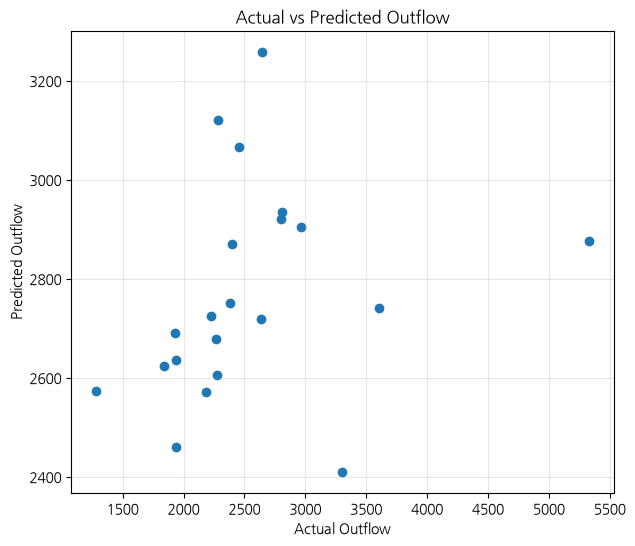

In [75]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Outflow")
plt.ylabel("Predicted Outflow")
plt.title("Actual vs Predicted Outflow")

plt.grid(alpha=0.3)
plt.show()

In [87]:
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, coefficient)

Intercept: 3364.598095004253
transactions 0.449475946378365
avg_price_m2 -0.6203858967328255
avg_build_age 6.957935575378732
avg_floor 131.0928097850782
district_강동구 -1557.7467652735436
district_송파구 -1298.413286988946


In [88]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 627.9447798221197
RMSE: 808.2059130063769
R²: -0.015591415736484038


## Observations for regression on Outflow with districts

- 

## Linear regression for inflow and Turnover

In [57]:
X = pd.get_dummies(
    combined_df[
        [
            "district",
            "transactions",
            "avg_price_m2",
            "avg_build_age",
            "avg_floor"
        ]
    ],
    columns=["district"],
    drop_first=True
)

y = combined_df['inflow']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.38, 0.24, 28.52, 41.82,-814.27, 215.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['transactions','avg_price_m2','avg_build_age','avg_floor','district_강동구', 'district_송파구']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,760.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [ ]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print(r2_score(y_test, dummy_pred))

-0.0020307067744935736


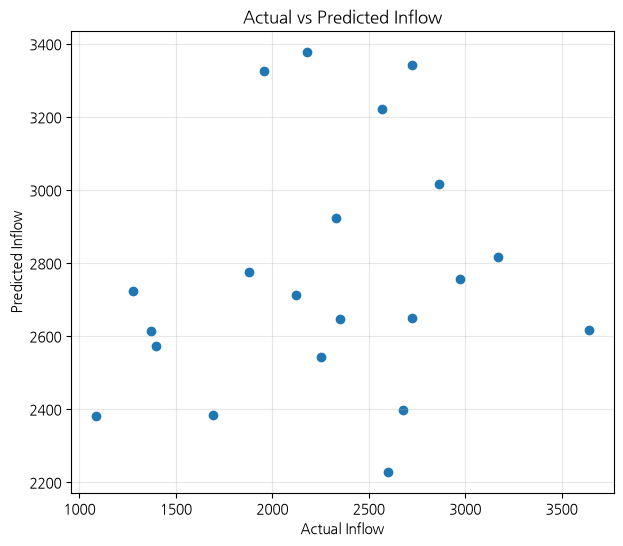

In [64]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Inflow")
plt.ylabel("Predicted Inflow")
plt.title("Actual vs Predicted Inflow")

plt.grid(alpha=0.3)
plt.show()

In [59]:
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, coefficient)

Intercept: 760.3737370733818
transactions 0.3804160415765708
avg_price_m2 0.23580375195441006
avg_build_age 28.520053250325866
avg_floor 41.82445780464857
district_강동구 -814.2657026306564
district_송파구 215.0388482122111


In [60]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 706.2921853423234
RMSE: 829.5076666349538
R²: -0.6219710884697067



| Target       |   MAE |  RMSE |         R² |
| ------------ | ----: | ----: | ---------: |
| **Outflow**  |   592 |   762 |  **** |
| **Inflow**   |   706 |   830 | **-0.622** |
| **Turnover** | 2,077 | 2,365 | **-2.657** |

